# Modelado Predictivo — Dataset Amazon
## PA02 — Analítica de Datos | Grupo 05 | USS 2026-I

In [1]:
# ============================================================
# CELDA 2: Importación de librerías
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8')
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# ============================================================
# CELDA 3: Cargar datos — con muestreo para velocidad
# ============================================================
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

X_train = joblib.load('modelos/X_train.pkl')
X_test  = joblib.load('modelos/X_test.pkl')
y_train = joblib.load('modelos/y_train.pkl')
y_test  = joblib.load('modelos/y_test.pkl')
scaler  = joblib.load('modelos/scaler.pkl')

# Reconstruir TotalAmount para crear el target
total_test  = X_test['TotalAmount']  * scaler.scale_[5] + scaler.mean_[5]
total_train = X_train['TotalAmount'] * scaler.scale_[5] + scaler.mean_[5]

# Target: 1 = Alto Valor, 0 = Bajo Valor
mediana = total_train.median()
y_train = (total_train > mediana).astype(int)
y_test  = (total_test  > mediana).astype(int)

# Eliminar variables trampa
vars_trampa = ['TotalAmount', 'UnitPrice', 'Tax', 'Discount']
X_train = X_train.drop(columns=vars_trampa)
X_test  = X_test.drop(columns=vars_trampa)

# Muestreo estratificado 20% para velocidad
X_train, _, y_train, _ = train_test_split(
    X_train, y_train,
    train_size=0.20,
    random_state=42,
    stratify=y_train
)

print("✅ Datos listos")
print(f"   Entrenamiento : {X_train.shape[0]:,} filas (20%)")
print(f"   Prueba        : {X_test.shape[0]:,} filas (100%)")
print(f"   Variables     : {X_train.shape[1]}")
print(f"   Alto valor train: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")

✅ Datos listos
   Entrenamiento : 16,000 filas (20%)
   Prueba        : 20,000 filas (100%)
   Variables     : 29
   Alto valor train: 8,000 (50.0%)


In [3]:
# ============================================================
# CELDA 3.5: Fix para error wmic en Windows 11
# ============================================================
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

print("✅ Fix de Windows aplicado — usando 1 núcleo")

✅ Fix de Windows aplicado — usando 1 núcleo


In [4]:
# ============================================================
# CELDA 4: Definición de los 4 algoritmos
# ============================================================
modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    )
}

print("✅ 4 modelos definidos")
for nombre in modelos:
    print(f"   → {nombre}")

✅ 4 modelos definidos
   → Regresión Logística
   → Random Forest
   → SVM
   → KNN


In [5]:
# ============================================================
# CELDA 5: Entrenamiento y evaluación de los 4 modelos
# (Esta celda puede tardar entre 5 y 10 minutos — es normal)
# ============================================================
resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"⏳ Entrenando: {nombre}...")

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predecir
    y_pred      = modelo.predict(X_test)
    y_pred_prob = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    resultados.append({
        'Modelo'   : nombre,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'AUC-ROC'  : round(auc,  4)
    })

    modelos_entrenados[nombre] = {
        'modelo'     : modelo,
        'y_pred'     : y_pred,
        'y_pred_prob': y_pred_prob
    }

    print(f"   ✅ {nombre} — F1: {f1:.4f} | AUC: {auc:.4f}")

print("\n✅ Todos los modelos entrenados correctamente")

⏳ Entrenando: Regresión Logística...
   ✅ Regresión Logística — F1: 0.7082 | AUC: 0.7947
⏳ Entrenando: Random Forest...


   ✅ Random Forest — F1: 0.6852 | AUC: 0.7498
⏳ Entrenando: SVM...


   ✅ SVM — F1: 0.7590 | AUC: 0.7875
⏳ Entrenando: KNN...


   ✅ KNN — F1: 0.6919 | AUC: 0.7340

✅ Todos los modelos entrenados correctamente


In [6]:
# ============================================================
# CELDA 6: Tabla comparativa de los 4 modelos
# ============================================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_resultados.index += 1

print("=" * 65)
print("TABLA COMPARATIVA DE MODELOS — MÉTRICAS DE EVALUACIÓN")
print("=" * 65)
print(df_resultados.to_string())
print("=" * 65)

# Identificar el ganador
ganador = df_resultados.iloc[0]['Modelo']
print(f"\n🏆 Modelo ganador: {ganador}")
print(f"   F1-Score : {df_resultados.iloc[0]['F1-Score']}")
print(f"   AUC-ROC  : {df_resultados.iloc[0]['AUC-ROC']}")

TABLA COMPARATIVA DE MODELOS — MÉTRICAS DE EVALUACIÓN
                Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
1                  SVM    0.7349     0.6929  0.8390    0.7590   0.7875
2  Regresión Logística    0.7122     0.7144  0.7022    0.7082   0.7947
3                  KNN    0.6822     0.6681  0.7174    0.6919   0.7340
4        Random Forest    0.6751     0.6612  0.7111    0.6852   0.7498

🏆 Modelo ganador: SVM
   F1-Score : 0.759
   AUC-ROC  : 0.7875


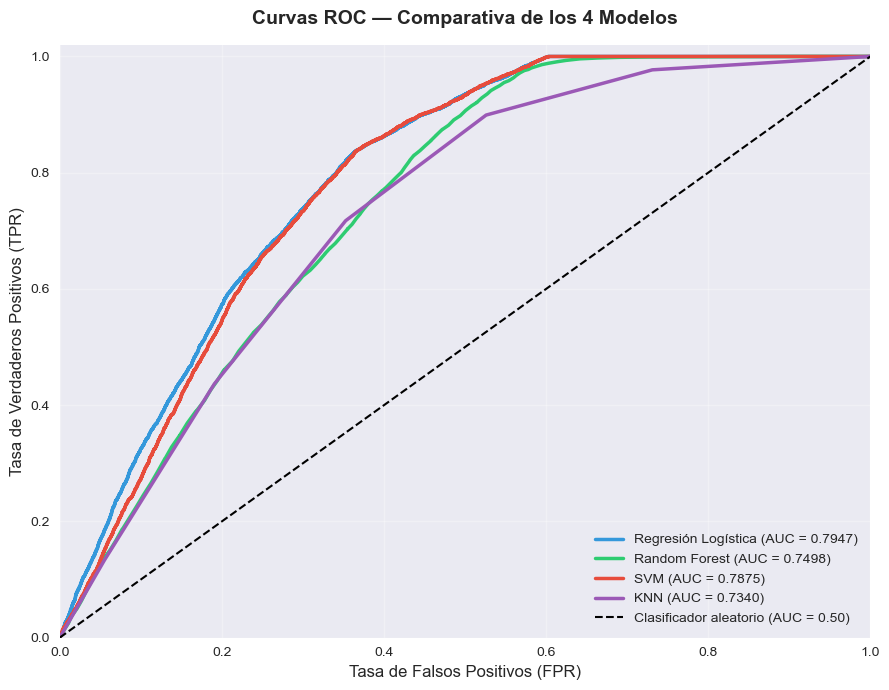

✅ Gráfica ROC guardada en /graficas


In [7]:
# ============================================================
# CELDA 7: Curvas ROC de los 4 modelos
# ============================================================
colores = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 7))

for (nombre, datos), color in zip(modelos_entrenados.items(), colores):
    fpr, tpr, _ = roc_curve(y_test, datos['y_pred_prob'])
    auc_val = roc_auc_score(y_test, datos['y_pred_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{nombre} (AUC = {auc_val:.4f})")

# Línea base (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador aleatorio (AUC = 0.50)')

ax.set_title('Curvas ROC — Comparativa de los 4 Modelos',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficas/grafica5_curvas_ROC.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica ROC guardada en /graficas")

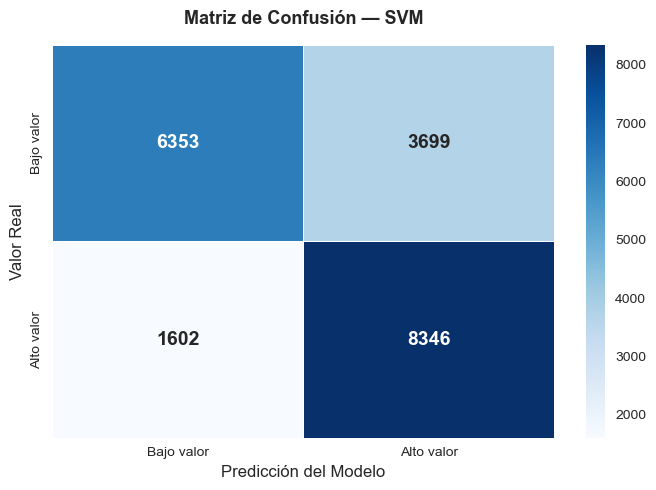

Verdaderos Negativos (TN) : 6,353  → predijo Bajo valor y era Bajo valor
Falsos Positivos     (FP) : 3,699  → predijo Alto valor pero NO lo era
Falsos Negativos     (FN) : 1,602  → predijo Bajo valor pero era Alto valor
Verdaderos Positivos (TP) : 8,346  → predijo Alto valor y era Alto valor

✅ Gráfica guardada en /graficas


In [8]:
# ============================================================
# CELDA 8: Matriz de confusión del modelo ganador
# ============================================================
y_pred_ganador = modelos_entrenados[ganador]['y_pred']
cm = confusion_matrix(y_test, y_pred_ganador)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo valor', 'Alto valor'],
            yticklabels=['Bajo valor', 'Alto valor'],
            linewidths=0.5, ax=ax,
            annot_kws={"size": 14, "weight": "bold"})

ax.set_title(f'Matriz de Confusión — {ganador}',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicción del Modelo', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)

plt.tight_layout()
plt.savefig('graficas/grafica6_confusion_ganador.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN) : {tn:,}  → predijo Bajo valor y era Bajo valor")
print(f"Falsos Positivos     (FP) : {fp:,}  → predijo Alto valor pero NO lo era")
print(f"Falsos Negativos     (FN) : {fn:,}  → predijo Bajo valor pero era Alto valor")
print(f"Verdaderos Positivos (TP) : {tp:,}  → predijo Alto valor y era Alto valor")
print(f"\n✅ Gráfica guardada en /graficas")

In [9]:
# ============================================================
# CELDA 9: Reporte de clasificación del modelo ganador
# ============================================================
print(f"REPORTE DETALLADO — {ganador}")
print("=" * 55)
print(classification_report(
    y_test,
    y_pred_ganador,
    target_names=['Bajo valor', 'Alto valor'],
    digits=4
))

REPORTE DETALLADO — SVM
              precision    recall  f1-score   support

  Bajo valor     0.7986    0.6320    0.7056     10052
  Alto valor     0.6929    0.8390    0.7590      9948

    accuracy                         0.7349     20000
   macro avg     0.7458    0.7355    0.7323     20000
weighted avg     0.7460    0.7349    0.7322     20000



In [10]:
# ============================================================
# CELDA 10: Guardar el modelo ganador para la Fase 4 (App web)
# ============================================================
modelo_final = modelos_entrenados[ganador]['modelo']

joblib.dump(modelo_final, 'modelos/modelo_ganador.pkl')
joblib.dump(ganador,      'modelos/nombre_ganador.pkl')

# Se guarda también la mediana real usada para etiquetar "alto valor"
# (calculada en la Celda 3). Antes este número se escribía a mano en
# app.py y aquí abajo (Chi-cuadrado), y ambos quedaron desincronizados
# del valor real de entrenamiento (714.31 vs el valor real de ~715.37).
# Guardarlo en un .pkl evita que vuelva a pasar si se reentrena el modelo.
joblib.dump(float(mediana), 'modelos/mediana.pkl')

print(f"✅ Modelo ganador guardado: {ganador}")
print(f"   Archivo: modelos/modelo_ganador.pkl")
print(f"   Mediana de entrenamiento guardada: modelos/mediana.pkl ({mediana:.2f})")
print(f"\n→ Este modelo será usado en la Fase 4 (App Streamlit)")


✅ Modelo ganador guardado: SVM
   Archivo: modelos/modelo_ganador.pkl

→ Este modelo será usado en la Fase 4 (App Streamlit)


In [11]:
# ============================================================
# Prueba Chi-cuadrado — PaymentMethod vs Valor del Pedido
# ============================================================
from scipy.stats import chi2_contingency
import pandas as pd

df_chi = pd.read_csv('data/Amazon.csv')
scaler_chi = joblib.load('modelos/scaler.pkl')

# Recrear target usando la MISMA mediana guardada en la Celda 10
# (antes estaba hardcodeada como 714.31, un valor distinto al usado
# realmente para entrenar el modelo — quedaba desincronizado).
mediana = joblib.load('modelos/mediana.pkl')
df_chi['AltoValor'] = (df_chi['TotalAmount'] > mediana).astype(int)

# Tabla de contingencia
tabla = pd.crosstab(df_chi['PaymentMethod'], df_chi['AltoValor'])
print("TABLA DE CONTINGENCIA")
print(tabla)

chi2, p_valor, gl, esperados = chi2_contingency(tabla)

print(f"\nEstadístico Chi²  : {chi2:.4f}")
print(f"p-valor           : {p_valor:.4f}")
print(f"Grados de libertad: {gl}")
print(f"\nConclusión: {'Se RECHAZA H₀ — existe relación significativa' if p_valor < 0.05 else 'NO se rechaza H₀ — no hay relación significativa'}")


TABLA DE CONTINGENCIA
AltoValor             0      1
PaymentMethod                 
Amazon Pay         7572   7445
Cash on Delivery   2444   2484
Credit Card       17613  17425
Debit Card         9917  10107
Net Banking        4999   4928
UPI                7455   7611

Estadístico Chi²  : 6.3334
p-valor           : 0.2751
Grados de libertad: 5

Conclusión: NO se rechaza H₀ — no hay relación significativa
